## Problema

Muchos pacientes no asisten a sus citas médicas o dentales, lo que provoca pérdida de tiempo y recursos para las clínicas.

## Objetivo

Entrenar un modelo de Machine Learning que prediga si un paciente asistirá o no a su cita utilizando datos históricos.

## Relación con el proyecto

El sistema Healthy-Reminder administra citas de pacientes en consultorios dentales. Este modelo podría integrarse al sistema para detectar pacientes con mayor probabilidad de faltar y enviar recordatorios automáticos.

In [ ]:
# importar librerías necesarias para manipular datos, visualizar información y entrenar el modelo
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# importar herramientas de machine learning de sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# cargar el dataset desde el archivo csv que contiene la información de citas médicas
data = pd.read_csv("data\KaggleV2-May-2016.csv")

# mostrar las primeras filas para conocer la estructura de los datos
data.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [ ]:
# mostrar información general del dataset como número de registros, columnas y tipos de datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [ ]:
# generar estadísticas descriptivas de las variables numéricas
data.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [ ]:
# verificar si existen valores nulos o faltantes en el dataset
data.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [ ]:
# convertir la variable objetivo "No-show" a valores numéricos para poder usarla en el modelo
# no = 0 (asistió) y yes = 1 (no asistió)
data['No-show'] = data['No-show'].map({'No':0, 'Yes':1})

In [ ]:
# seleccionar las variables que se utilizarán como entrada del modelo
# estas variables representan características del paciente
X = data[['Age','Hipertension','Diabetes','Alcoholism','SMS_received']]

# definir la variable objetivo que el modelo intentará predecir
y = data['No-show']

In [ ]:
# dividir los datos en conjunto de entrenamiento y conjunto de prueba
# 80% se usa para entrenar el modelo y 20% para evaluarlo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# crear el modelo de árbol de decisión que se utilizará para la predicción
model = DecisionTreeClassifier()

# entrenar el modelo utilizando los datos de entrenamiento
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
# utilizar el modelo entrenado para realizar predicciones con los datos de prueba
y_pred = model.predict(X_test)

In [ ]:
# calcular la precisión del modelo comparando las predicciones con los valores reales
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy del modelo:", accuracy)

Accuracy del modelo: 0.7986519496969149


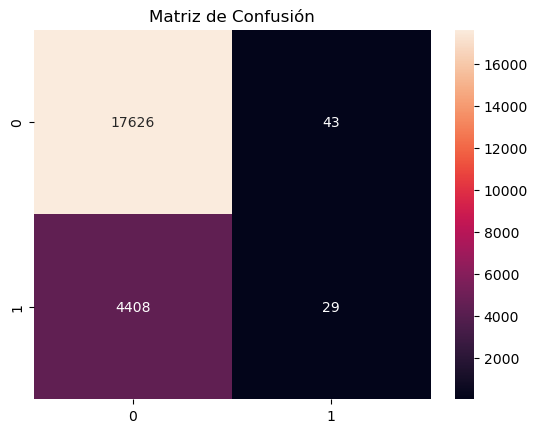

In [ ]:
# generar la matriz de confusión para evaluar el desempeño del modelo
# esta matriz muestra aciertos y errores en las predicciones
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Matriz de Confusión")
plt.show()

In [ ]:
# mostrar métricas adicionales como precisión, recall y f1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     17669
           1       0.40      0.01      0.01      4437

    accuracy                           0.80     22106
   macro avg       0.60      0.50      0.45     22106
weighted avg       0.72      0.80      0.71     22106



## Evaluación del modelo

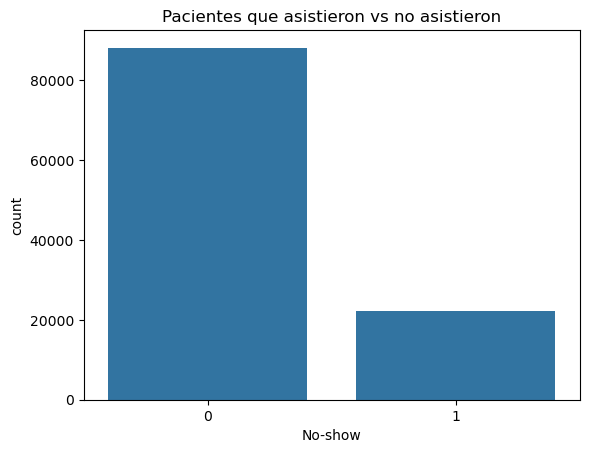

In [ ]:
# visualizar cuántos pacientes asistieron y cuántos no asistieron a sus citas
sns.countplot(x='No-show', data=data)
plt.title("Pacientes que asistieron vs no asistieron")
plt.show()

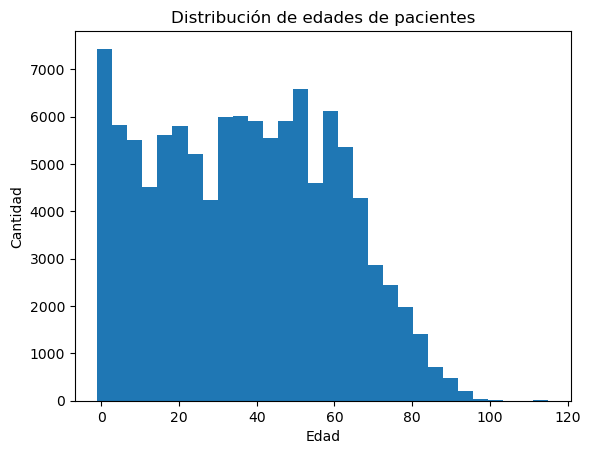

In [ ]:
# mostrar la distribución de edades de los pacientes en el dataset
plt.hist(data['Age'], bins=30)
plt.title("Distribución de edades de pacientes")
plt.xlabel("Edad")
plt.ylabel("Cantidad")
plt.show()

## Conclusión

El modelo de árbol de decisión fue entrenado utilizando información de los pacientes como edad, hipertensión, diabetes, alcoholismo y recordatorios SMS. El modelo alcanzó una precisión aproximada del 80%.

Sin embargo, debido al desbalance en el dataset, el modelo tiene dificultades para identificar correctamente a los pacientes que no asisten a sus citas. Aun así, este tipo de modelo podría integrarse en el sistema Healthy-Reminder para identificar pacientes con mayor probabilidad de faltar y enviar recordatorios automáticos.